In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [101]:
pd.set_option('display.max_columns', None)

1. Data Loading and Preprocessing

In [102]:
# Load Data
train_file_path = 'Train.csv'
test_file_path = 'Test.csv'

df = pd.read_csv(train_file_path, sep=',')
df_test = pd.read_csv(test_file_path, sep=',')

C:\Users\A01411\AppData\Local\Temp\ipykernel_9672\1315461654.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(train_file_path, sep=',')


In [103]:
df.drop('Object_Name', axis=1, inplace=True)
df_test.drop('Object_Name', axis=1, inplace=True)
df['Timestamp'].fillna(" ", inplace=True)
df_test['Timestamp'].fillna(" ", inplace=True)

df_X = df.drop(['Timestamp', 'target_feature'], axis=1)
df_X.fillna(0, inplace=True)

features = df_X.drop(['Frame', 'Time'], axis=1)
feature_columns = features.columns

features = df_X.drop(['Frame', 'Time'], axis=1)

feature_columns = list(features.columns)

stats = ["min", "max", "mean", "std"]
feature_names = [f"{col}_{stat}" for col in feature_columns for stat in stats]


C:\Users\A01411\AppData\Local\Temp\ipykernel_9672\2032992884.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Timestamp'].fillna(" ", inplace=True)
C:\Users\A01411\AppData\Local\Temp\ipykernel_9672\2032992884.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

2. Data Exploration & Visualization

SAMPLE LENGTH ANALYSIS

Samples per participant:
target_feature
Abir          8820
Akbar       131760
Daniel       71835
Fardin       26715
Marian       33690
Maurice      47070
Oguz        167970
Reza         14061
Spieler4     39600
Spieler5     33270
dtype: int64

Total samples: 574791
Mean samples per participant: 57479.1
Std samples per participant: 52399.4


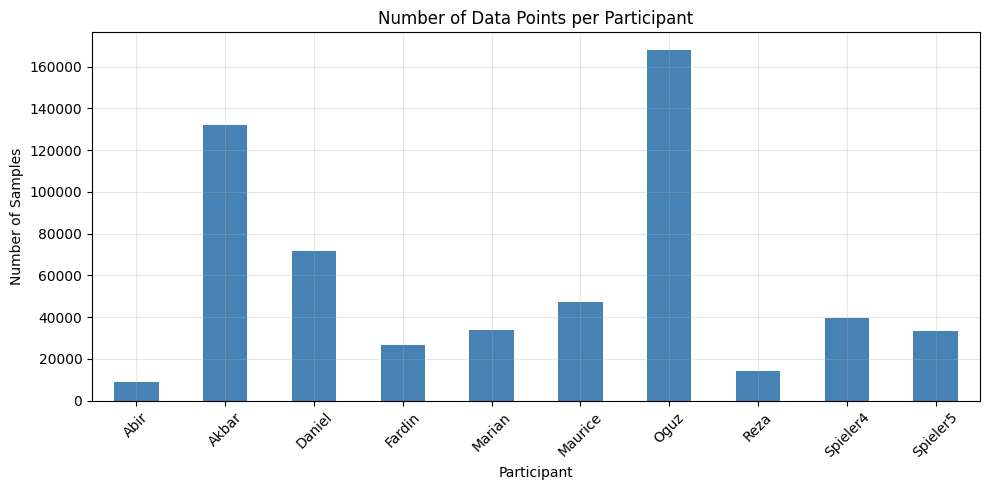

In [104]:
# 2.1 Sample Length Distribution
print("=" * 60)
print("SAMPLE LENGTH ANALYSIS")
print("=" * 60)

sample_lengths = df.groupby('target_feature').size()
print(f"\nSamples per participant:\n{sample_lengths}")
print(f"\nTotal samples: {len(df)}")
print(f"Mean samples per participant: {sample_lengths.mean():.1f}")
print(f"Std samples per participant: {sample_lengths.std():.1f}")

# Plot sample lengths
plt.figure(figsize=(10, 5))
sample_lengths.plot(kind='bar', color='steelblue')
plt.title('Number of Data Points per Participant')
plt.xlabel('Participant')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

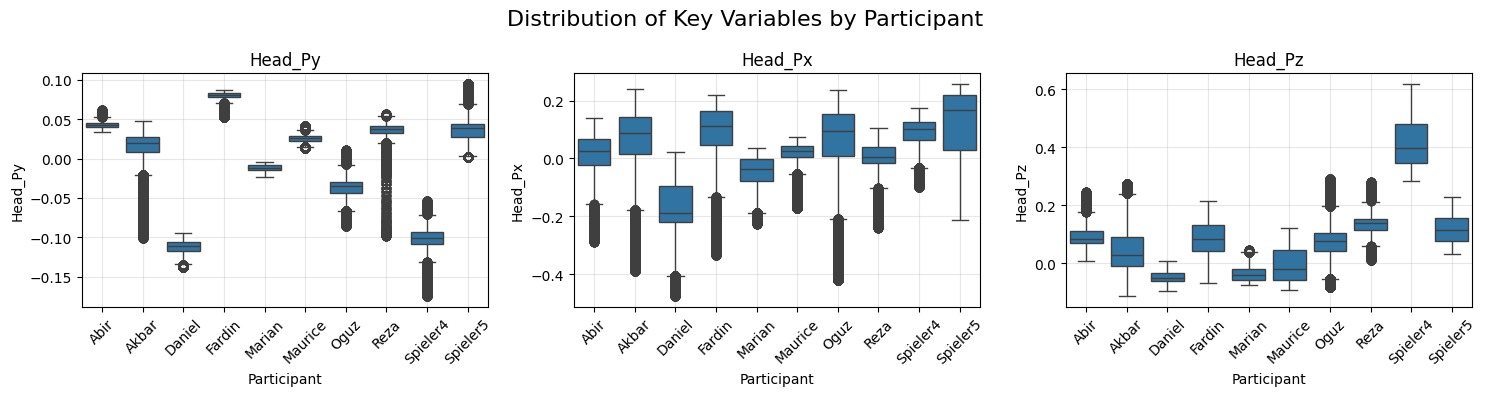

In [105]:
# 2.2 Boxplots of Key Variables (first 3 only)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribution of Key Variables by Participant', fontsize=16)

key_vars = ['Head_Py', 'Head_Px', 'Head_Pz']
available_vars = [var for var in key_vars if var in df.columns][:3]

for idx, var in enumerate(available_vars):
    ax = axes[idx]
    sns.boxplot(data=df, x='target_feature', y=var, ax=ax)
    ax.set_title(var)
    ax.set_xlabel('Participant')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


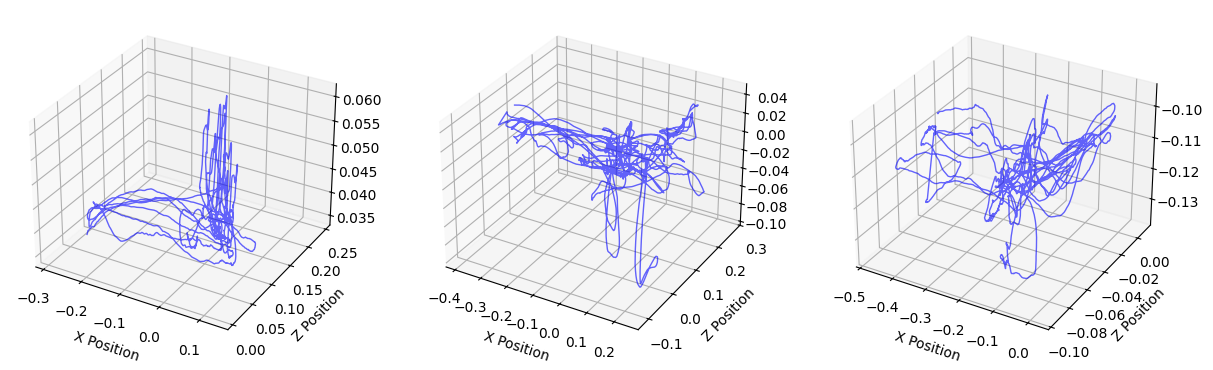

In [106]:
# Movement trajectories
participants = df['target_feature'].unique()[:3]

fig = plt.figure(figsize=(15, 5))

for idx, participant in enumerate(participants, 1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')
    participant_data = df[df['target_feature'] == participant]
    
    if all(col in df.columns for col in ['Head_Px', 'Head_Pz', 'Head_Py']):
        ax.plot(participant_data['Head_Px'], 
                participant_data['Head_Pz'], 
                participant_data['Head_Py'], 
                label='Head', alpha=0.6, linewidth=1, color='blue')
    
    if all(col in df.columns for col in ['RightHand_Px', 'RightHand_Pz', 'RightHand_Py']):
        ax.plot(participant_data['RightHand_Px'], 
                participant_data['RightHand_Pz'], 
                participant_data['RightHand_Py'], 
                label='Right Hand', alpha=0.6, linewidth=1, color='red')
    
    ax.set_xlabel('X Position')
    ax.set_ylabel('Z Position')

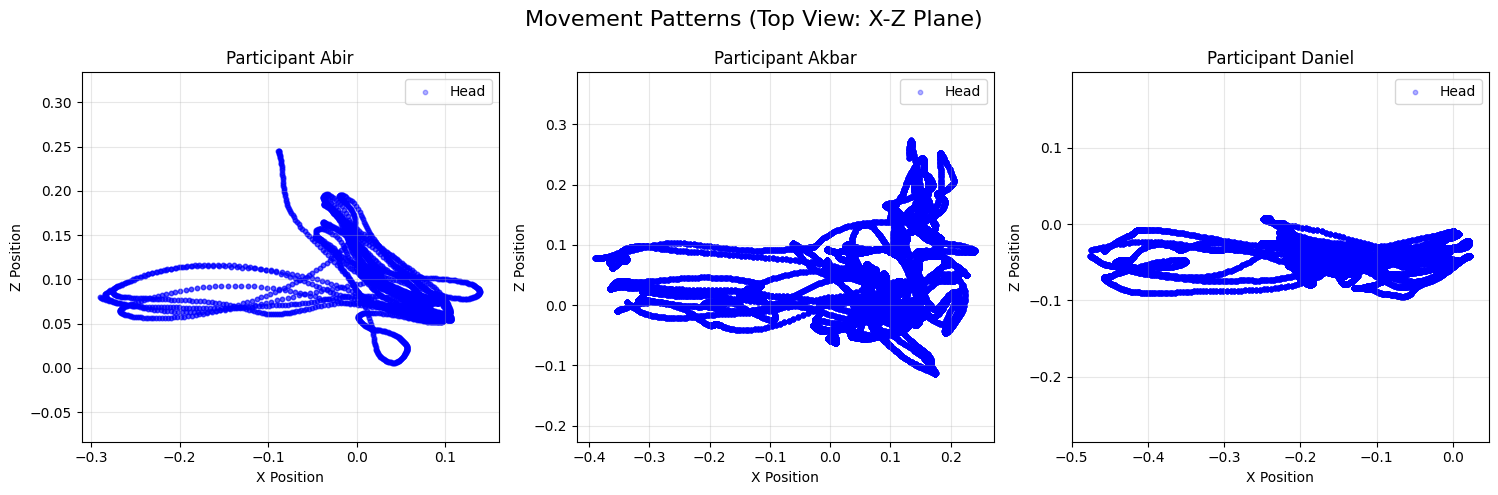

In [107]:
# 2.4 2D Movement Patterns (Top View)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Movement Patterns (Top View: X-Z Plane)', fontsize=16)

for idx, participant in enumerate(participants):
    ax = axes[idx]
    participant_data = df[df['target_feature'] == participant]
    
    if all(col in df.columns for col in ['Head_Px', 'Head_Pz']):
        ax.scatter(participant_data['Head_Px'], participant_data['Head_Pz'], 
                  alpha=0.3, s=10, label='Head', c='blue')
    
    # Plot hand movement (if columns exist)
    if all(col in df.columns for col in ['RightHand_Px', 'RightHand_Pz']):
        ax.scatter(participant_data['RightHand_Px'], participant_data['RightHand_Pz'], 
                  alpha=0.3, s=10, label='Right Hand', c='red')
    
    ax.set_xlabel('X Position')
    ax.set_ylabel('Z Position')
    ax.set_title(f'Participant {participant}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

plt.tight_layout()
plt.show()

3. Preprocessing (Feature Extraction)

In [108]:
def process_data(dataframe):
    import numpy as np

    # repetition_id pro Spieler anhand "SessionStarted" markieren
    def assign_repetition_ids(group):
        is_marker = group['Timestamp'].astype(str).str.contains('SessionStarted', na=False)
        rising_edge = is_marker & (~is_marker.shift(1).fillna(False))
        group['repetition_id'] = rising_edge.cumsum()
        return group

    dataframe = dataframe.groupby('target_feature', group_keys=False).apply(assign_repetition_ids)

    # alles vor der ersten Session raus
    dataframe = dataframe[dataframe['repetition_id'] > 0]

    features_out = []
    labels_out = []

    # jetzt pro Session (3 Würfe Block) aggregieren
    grouped = dataframe.groupby(['target_feature', 'repetition_id'])

    for (participant, rep_id), group in grouped:
        group = group.copy()

        # ================================
        # Session-basierte Height-Normalisierung (ohne Leakage)
        # ================================
        # Nutzt nur Daten IN DIESER SESSION (kein target_feature-Wissen nötig)
        if 'Head_Py' in group.columns:
            head_height = np.nanmedian(group['Head_Py'].values)
            if np.isfinite(head_height) and head_height != 0:
                for col in feature_columns:
                    # nur Y-Positions-Spalten normalisieren, z.B. Head_Py, Right_Py, Left_Py, Obj_Py
                    if col.endswith('_Py') and col in group.columns:
                        group[col] = group[col] / head_height

        sample_features = []

        # min/max/mean/std pro Feature
        for col in feature_columns:
            if col in group.columns:
                series = group[col]
                sample_features.extend([series.min(), series.max(), series.mean(), series.std()])
            else:
                sample_features.extend([0, 0, 0, 0])

        features_out.append(sample_features)
        labels_out.append(participant)

    return features_out, labels_out


4. Model Training & Evaluation

In [109]:
print("Processing Training Data...")
X_train_list, y_train_list = process_data(df)

print("Processing Testing Data...")
X_test_list, y_test_list = process_data(df_test)
X_train = np.nan_to_num(X_train_list)
X_test = np.nan_to_num(X_test_list)

Processing Training Data...


C:\Users\A01411\AppData\Local\Temp\ipykernel_9672\2772833457.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rising_edge = is_marker & (~is_marker.shift(1).fillna(False))
C:\Users\A01411\AppData\Local\Temp\ipykernel_9672\2772833457.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rising_edge = is_marker & (~is_marker.shift(1).fillna(False))
C:\Users\A01411\AppData\Local\Temp\ipykernel_9672\2772833457.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_

Processing Testing Data...


C:\Users\A01411\AppData\Local\Temp\ipykernel_9672\2772833457.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rising_edge = is_marker & (~is_marker.shift(1).fillna(False))
C:\Users\A01411\AppData\Local\Temp\ipykernel_9672\2772833457.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rising_edge = is_marker & (~is_marker.shift(1).fillna(False))
C:\Users\A01411\AppData\Local\Temp\ipykernel_9672\2772833457.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_

In [110]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_list)
y_test_encoded = le.transform(y_test_list)

In [111]:
# Model Definition
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, min_samples_split=5, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, subsample=0.8, eval_metric='logloss', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42)
}

In [112]:
confusion_matrices = {}

print("\n--- Model Evaluation Results ---\n")

for name, clf in models.items():
    print(f"Training {name}...")
    
    clf.fit(X_train, y_train_encoded)
    predictions_encoded = clf.predict(X_test)
    predictions_strings = le.inverse_transform(predictions_encoded)
    acc = accuracy_score(y_test_list, predictions_strings)
    print(f"Accuracy: {acc * 100:.2f}%")

    # Classification Report (Precision, Recall, F1-Score)
    print("\n--- Classification Report ---")
    print(classification_report(y_test_list, predictions_strings, labels=le.classes_, target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test_list, predictions_strings, labels=le.classes_)
    confusion_matrices[name] = cm


--- Model Evaluation Results ---

Training Decision Tree...
Accuracy: 54.55%

--- Classification Report ---
              precision    recall  f1-score   support

        Abir       0.00      0.00      0.00         1
       Akbar       0.50      1.00      0.67         1
      Daniel       0.00      0.00      0.00         1
      Fardin       1.00      1.00      1.00         1
      Marian       0.00      0.00      0.00         1
     Maurice       1.00      1.00      1.00         1
        Oguz       0.67      1.00      0.80         2
        Reza       0.00      0.00      0.00         1
    Spieler4       0.00      0.00      0.00         1
    Spieler5       0.50      1.00      0.67         1

    accuracy                           0.55        11
   macro avg       0.37      0.50      0.41        11
weighted avg       0.39      0.55      0.45        11

Training Random Forest...


C:\Users\A01411\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\A01411\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\A01411\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_c

Accuracy: 100.00%

--- Classification Report ---
              precision    recall  f1-score   support

        Abir       1.00      1.00      1.00         1
       Akbar       1.00      1.00      1.00         1
      Daniel       1.00      1.00      1.00         1
      Fardin       1.00      1.00      1.00         1
      Marian       1.00      1.00      1.00         1
     Maurice       1.00      1.00      1.00         1
        Oguz       1.00      1.00      1.00         2
        Reza       1.00      1.00      1.00         1
    Spieler4       1.00      1.00      1.00         1
    Spieler5       1.00      1.00      1.00         1

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11

Training Gradient Boosting...
Accuracy: 63.64%

--- Classification Report ---
              precision    recall  f1-score   support

        Abir       0.00      0.00      0.00         1
     

C:\Users\A01411\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\A01411\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\A01411\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_c

Accuracy: 72.73%

--- Classification Report ---
              precision    recall  f1-score   support

        Abir       1.00      1.00      1.00         1
       Akbar       0.00      0.00      0.00         1
      Daniel       0.00      0.00      0.00         1
      Fardin       1.00      1.00      1.00         1
      Marian       1.00      1.00      1.00         1
     Maurice       1.00      1.00      1.00         1
        Oguz       1.00      1.00      1.00         2
        Reza       0.50      1.00      0.67         1
    Spieler4       0.50      1.00      0.67         1
    Spieler5       0.00      0.00      0.00         1

    accuracy                           0.73        11
   macro avg       0.60      0.70      0.63        11
weighted avg       0.64      0.73      0.67        11



C:\Users\A01411\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\A01411\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\A01411\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_c

In [113]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, make_scorer, accuracy_score
import numpy as np

X_all = X_train
y_all = y_train_encoded

print(f"\nDataset: {len(y_all)} samples, {len(set(y_all))} participants")
print(f"Features: {X_all.shape[1]} (40 sensors × 4 statistics)")
print(f"Evaluation: 3-Fold Stratified Cross-Validation\n")
final_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=3,
        max_features='sqrt',
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        eval_metric='logloss',
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        C=1.0,
        random_state=42
    )
}

# Perform cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("-" * 60)
print("Model Performance (3-Fold Cross-Validation):")
print("-" * 60)

results_summary = []
for name, model in final_models.items():
    scores = cross_val_score(model, X_all, y_all, cv=cv, scoring='accuracy')
    mean_score = scores.mean()
    std_score = scores.std()

    print(f"\n{name}:")
    print(f"  Accuracy: {mean_score*100:.2f}% (±{std_score*100:.2f}%)")
    print(f"  Fold scores: {[f'{s*100:.2f}%' for s in scores]}")

    results_summary.append({
        'Model': name,
        'Mean Accuracy': f"{mean_score*100:.2f}%",
        'Std Dev': f"±{std_score*100:.2f}%"
    })

print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)


Dataset: 38 samples, 10 participants
Features: 160 (40 sensors × 4 statistics)
Evaluation: 3-Fold Stratified Cross-Validation

------------------------------------------------------------
Model Performance (3-Fold Cross-Validation):
------------------------------------------------------------

Random Forest:
  Accuracy: 89.32% (±4.23%)
  Fold scores: ['92.31%', '92.31%', '83.33%']

Gradient Boosting:
  Accuracy: 75.85% (±12.39%)
  Fold scores: ['84.62%', '84.62%', '58.33%']

XGBoost:
  Accuracy: 76.07% (±7.35%)
  Fold scores: ['84.62%', '76.92%', '66.67%']

Logistic Regression:
  Accuracy: 55.13% (±4.80%)
  Fold scores: ['53.85%', '61.54%', '50.00%']

SUMMARY TABLE


## Best Models Visualization

DETAILED VISUALIZATION FOR BEST MODELS

Random Forest:
  Fold 1: 92.31%
  Fold 2: 92.31%
  Fold 3: 83.33%


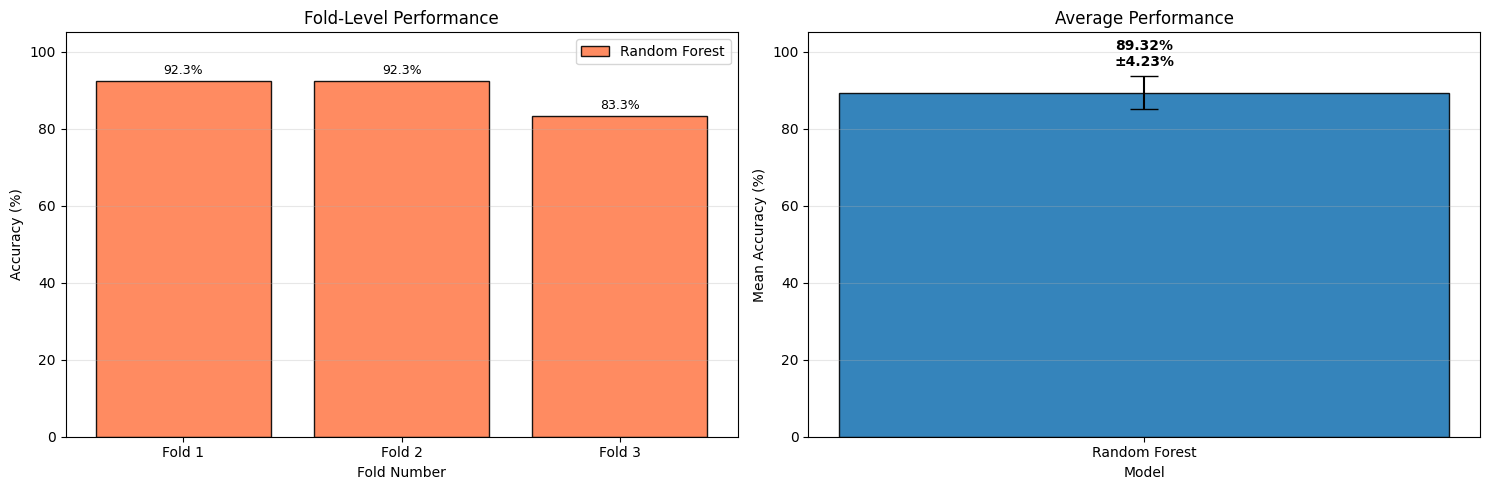

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

print("=" * 60)
print("DETAILED VISUALIZATION FOR BEST MODELS")
print("=" * 60)

best_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_split=3,
        max_features='sqrt', random_state=42
    )
}

fold_results = {name: [] for name in best_models.keys()}
cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in best_models.items():
    cv_results = cross_validate(model, X_all, y_all, cv=cv_splitter,
                                scoring='accuracy', return_train_score=True)
    fold_results[name] = cv_results['test_score']
    print(f"\n{name}:")
    for fold_idx, score in enumerate(cv_results['test_score'], 1):
        print(f"  Fold {fold_idx}: {score*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax1, ax2 = axes

x_pos = np.arange(cv_splitter.get_n_splits())

rf_scores = fold_results['Random Forest'] * 100

bars1 = ax1.bar(x_pos, rf_scores, label='Random Forest', edgecolor='black', alpha=0.9, color='coral')

ax1.set_xlabel('Fold Number')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Fold-Level Performance')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'Fold {i+1}' for i in x_pos])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 105])

for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 1, f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

model_names = list(best_models.keys())
mean_scores = [fold_results[n].mean() * 100 for n in model_names]
std_scores  = [fold_results[n].std() * 100 for n in model_names]

ax2.bar(range(len(model_names)), mean_scores, yerr=std_scores, capsize=10, edgecolor='black', alpha=0.9)
ax2.set_xlabel('Model')
ax2.set_ylabel('Mean Accuracy (%)')
ax2.set_title('Average Performance')
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0, 105])

for i, (m, s) in enumerate(zip(mean_scores, std_scores)):
    ax2.text(i, m + s + 2, f'{m:.2f}%\n±{s:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()



CONFUSION MATRIX: RANDOM FOREST (3-FOLD CV)


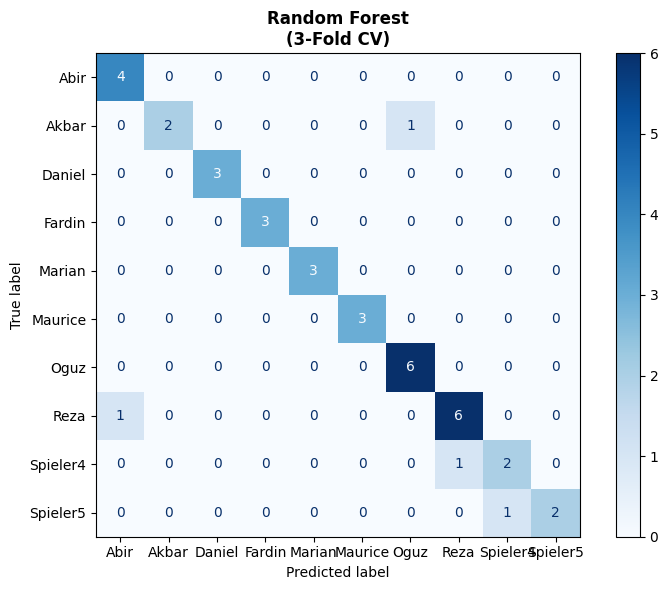


CLASSIFICATION REPORT: RANDOM FOREST (3-FOLD CV)
              precision    recall  f1-score   support

        Abir      0.800     1.000     0.889         4
       Akbar      1.000     0.667     0.800         3
      Daniel      1.000     1.000     1.000         3
      Fardin      1.000     1.000     1.000         3
      Marian      1.000     1.000     1.000         3
     Maurice      1.000     1.000     1.000         3
        Oguz      0.857     1.000     0.923         6
        Reza      0.857     0.857     0.857         7
    Spieler4      0.667     0.667     0.667         3
    Spieler5      1.000     0.667     0.800         3

    accuracy                          0.895        38
   macro avg      0.918     0.886     0.894        38
weighted avg      0.904     0.895     0.892        38



In [115]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("\n" + "=" * 60)
print("CONFUSION MATRIX: RANDOM FOREST (3-FOLD CV)")
print("=" * 60)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

model = best_models['Random Forest']
y_pred = cross_val_predict(model, X_all, y_all, cv=cv)
cm = confusion_matrix(y_all, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=True)
ax.set_title('Random Forest\n(3-Fold CV)', fontsize=12, fontweight='bold')
ax.grid(False)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT: RANDOM FOREST (3-FOLD CV)")
print("=" * 60)
print(classification_report(y_all, y_pred, target_names=le.classes_, digits=3))



FEATURE IMPORTANCE: RANDOM FOREST

Top 20 Most Important Features:
   1. Head_Qz_mean                   0.0269
   2. Head_Pz_min                    0.0253
   3. Right_Qx_max                   0.0215
   4. Right_Py_mean                  0.0214
   5. Head_Qw_max                    0.0212
   6. Head_Rz_mean                   0.0204
   7. Head_Qx_max                    0.0202
   8. Right_Py_min                   0.0200
   9. Head_Qz_max                    0.0198
  10. Head_Qw_std                    0.0186
  11. Right_Py_max                   0.0184
  12. Head_Qw_min                    0.0178
  13. Head_Pz_mean                   0.0176
  14. Head_Qx_mean                   0.0169
  15. Right_Qx_mean                  0.0165
  16. Right_Ry_std                   0.0156
  17. Head_Qz_min                    0.0144
  18. Head_Pz_max                    0.0132
  19. Right_Qx_min                   0.0131
  20. Obj_Qz_std                     0.0130


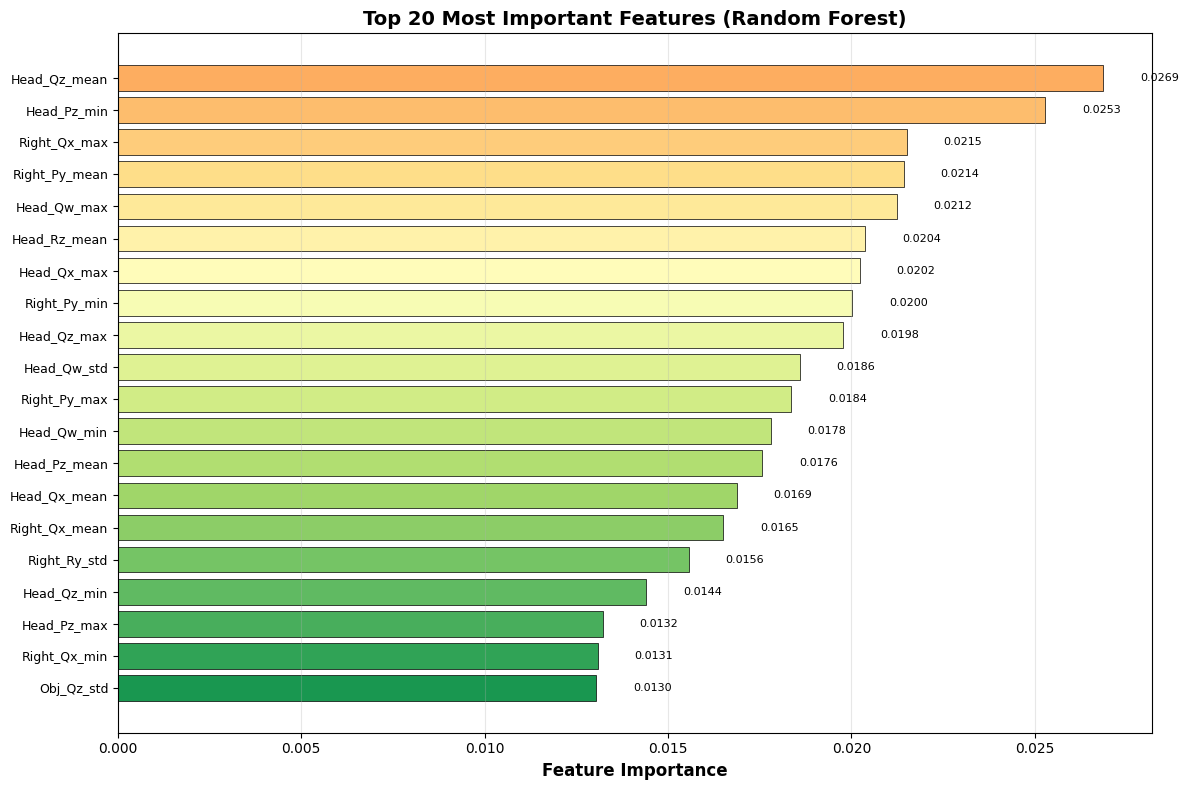

In [116]:
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE: RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=3,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_all, y_all)

# Get feature importance
feature_importance = rf_model.feature_importances_
feature_importance = rf_model.feature_importances_

sensor_names = list(feature_columns)
stat_names = ['min', 'max', 'mean', 'std']
feature_names = []
for sensor in sensor_names:
    for stat in stat_names:
        feature_names.append(f"{sensor}_{stat}")

# Get top 20 most important features
top_n = 20
importance_indices = np.argsort(feature_importance)[-top_n:][::-1]
top_features = [feature_names[i] for i in importance_indices]
top_importance = feature_importance[importance_indices]

print(f"\nTop {top_n} Most Important Features:")
for i, (feat, imp) in enumerate(zip(top_features, top_importance), 1):
    print(f"  {i:2d}. {feat:<30s} {imp:.4f}")

# Visualize top features
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))
bars = ax.barh(range(top_n), top_importance, color=colors, edgecolor='black', linewidth=0.5)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features, fontsize=9)
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_title(f'Top {top_n} Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_importance)):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


## Results

### Cross-Validation Performance:

| Model | Mean Accuracy | Std Dev |
|-------|--------------|---------|
| **Random Forest** | **89.32%** | **+/-4.23%** |
| XGBoost | 76.07% | +/-7.35% |
| Gradient Boosting | 75.85% | ±12.39% |
| Logistic Regression | 55.13% | +/-4.8% |


### Key Findings:
1. Reliable user identification was achieved with Random Forest, reaching nearly 90% accuracy across cross-validation folds.
2. **Tree-based ensemble models (Random Forest, XGBoost)** clearly outperformed linear models, indicating 
   strong non-linear patterns in the movement data.
3. **Session-based height normalization reduced body-size bias** and improved generalization across participants with different physical
   characteristics.
4. **Head rotation and right-hand movement features** were the most informative, highlighting the importance of fine-grained motion behavior
   rather than static positional cues.

### Model Comparison Visualizations:
- The **Random Forest confusion matrix** showed a strong diagonal structure, with only a few misclassifications between specific participants.
- Most users were consistently identified across folds, indicating stable behavioral patterns.

### Feature Importance Analysis
The Random Forest model identified the following feature groups as most influential:
- **Head rotation (quaternions: Qx, Qz, Qw; rotation around Z-axis)**
- **Head vertical and depth movement (Pz, Py statistics)**
- **Right-hand vertical position and rotation features**

This suggests that **subtle head orientation changes and dominant-hand motion patterns** play a key role in distinguishing users.
This suggests that **subtle head orientation changes and dominant-hand motion patterns** play a key role in distinguishing users.
## Limitations

1. **Small sample size:** Only **38 session-level samples** across **10 participants**, limiting statistical power and generalization.
1. **Small sample size:** Only **38 session-level samples** across **10 participants**, limiting statistical power and generalization.
2. **High dimensionality:** **160 features** for a small number of samples increases the risk of overfitting.
3. **Simple temporal aggregation:** Only min/max/mean/std were used; no velocity, acceleration, or frequency-based features were extracted.
4. **Cross-validation granularity:** Standard stratified CV does not fully account for potential session-level or temporal dependencies.
5. **Dataset imbalance:** Large differences in raw data length per participant may still influence learned representations.

## Future Work
Data & Features: Expand the dataset with more participants, samples, and tasks while engineering advanced features like velocity, acceleration, and rotation using frequency analysis and dimensionality reduction.
- **Data & Features:** Expand the dataset with more participants, samples, and tasks while engineering advanced features like velocity, acceleration, and rotation using frequency analysis and dimensionality reduction.
- **Modeling & Validation:** Move to Deep Learning architectures (LSTMs, CNNs) and implement stricter validation strategies, such as session-based cross-validation, to ensure generalization.